In [ ]:
# This analysis will be pertaining to NYC Public Schools and student test performance, focusing on the Mean Score of the Regents Exam of Queens' schools vs. other boroughs' schools, compared to a single school: Forest Hills High School. The analysis will cover Regents exam score by borough, and will both clean the data and create a visualization from it. 

In [18]:
# import packages
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [197]:
# import data on NYC schools and student performance as schools_data
schools_data = pd.read_csv("https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv")

In [345]:
schools_data.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [346]:
# A quick data overview
schools_data.shape

(212331, 15)

In [347]:
schools_data.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [348]:
sd.head(20)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.4,3,33.3,6,66.7,0,0,na,na
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.6,2,13.3,13,86.7,5,33.3,na,na
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.4,5,55.6,4,44.4,1,11.1,na,na
8,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2015,49,78.4,1,2,48,98,23,46.9,48,98
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79,9,17.6,42,82.4,33,64.7,40,78.4


In [349]:
schools_data.info

<bound method DataFrame.info of        School DBN                     School Name School Level  \
0          01M034  P.S. 034 Franklin D. Roosevelt          K-8   
1          01M034  P.S. 034 Franklin D. Roosevelt          K-8   
2          01M034  P.S. 034 Franklin D. Roosevelt          K-8   
3          01M140          P.S. 140 Nathan Straus          K-8   
4          01M140          P.S. 140 Nathan Straus          K-8   
...           ...                             ...          ...   
212326     84X717            Icahn Charter School          K-8   
212327     84X717            Icahn Charter School          K-8   
212328     84X717            Icahn Charter School          K-8   
212329     84X717            Icahn Charter School          K-8   
212330     84X717            Icahn Charter School          K-8   

                       Regents Exam  Year  Total Tested Mean Score  \
0               Common Core Algebra  2017             4          s   
1                Living Environment

In [350]:
schools_data.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [351]:
# To start analyzing the data, we need to first clean it.
# Missing values are identified with "s" or "na"
# First, we will drop the "Number Scoring CR" and "Percent Scoring CR" in a new dataset, while keeping the original dataset intact.
sd1 = schools_data.drop('Number Scoring CR', axis=1)

In [352]:
sd1 = sd1.drop('Percent Scoring CR', axis=1)

In [353]:
# A quick check
sd1.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s


In [354]:
# We will drop the rows that contain "s", as these rows lack sufficient data to perform our analyses on.


In [355]:
sd1 = sd1[sd1['Mean Score'] != 's']

In [356]:
# A quick check
sd1.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.4,3,33.3,6,66.7,0,0
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.6,2,13.3,13,86.7,5,33.3
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.4,5,55.6,4,44.4,1,11.1


In [357]:
sd1

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.4,3,33.3,6,66.7,0,0
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.6,2,13.3,13,86.7,5,33.3
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.4,5,55.6,4,44.4,1,11.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
212321,84X717,Icahn Charter School,K-8,Common Core Algebra,2016,6,87.2,0,0,6,100,6,100
212322,84X717,Icahn Charter School,K-8,Common Core Algebra,2017,6,87,0,0,6,100,6,100
212323,84X717,Icahn Charter School,K-8,Common Core Algebra,2017,6,88.3,0,0,6,100,5,83.3
212324,84X717,Icahn Charter School,K-8,Living Environment,2015,8,76.5,1,12.5,7,87.5,2,25


In [358]:
# We will now convert the Mean Score column to numeric and remove all NA values
sd1['Mean Score'] = pd.to_numeric(sd1['Mean Score'], errors='coerce')

In [359]:
sd1['Mean Score'].dropna()

1         77.9
2         74.0
5         67.4
6         72.6
7         64.4
          ... 
212321    87.2
212322    87.0
212323    88.3
212324    76.5
212325    79.8
Name: Mean Score, Length: 137109, dtype: float64

In [360]:
# Now that our data is cleaned, we can begin to perform analyses.
# We will be comparing Queens' schools Mean Score to other boroughs' schools, as well as using Forest Hills High School as a single school reference.
# To begin, we will differentiate the schools.
# Queens' schools DBN contains the letter Q, so we will create a data set that separates them.
Queens = sd1[sd1['School DBN'].str.contains("Q")]

In [361]:
Queens

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above
13095,24Q457,H.S. Arts & Business Yabc,High school,English,2016,20,55.5,13,65,7,35,0,0
13364,24Q005,I.S. 5 - The Walter Crowley Intermediate School,Junior High-Intermediate-Middle,Common Core Algebra,2015,89,82.9,0,0,89,100,52,58.4
13365,24Q005,I.S. 5 - The Walter Crowley Intermediate School,Junior High-Intermediate-Middle,Common Core Algebra,2016,90,86.5,0,0,90,100,87,96.7
13366,24Q005,I.S. 5 - The Walter Crowley Intermediate School,Junior High-Intermediate-Middle,Common Core Algebra,2017,92,89.7,0,0,92,100,84,91.3
13370,24Q005,I.S. 5 - The Walter Crowley Intermediate School,Junior High-Intermediate-Middle,Physical Settings/Earth Science,2015,88,84.7,0,0,88,100,67,76.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
210600,84Q706,Our World Neighborhood Charter School,K-8,Common Core Algebra,2016,6,84.0,0,0,6,100,4,66.7
210604,84Q706,Our World Neighborhood Charter School,K-8,Common Core Algebra,2017,8,89.9,0,0,8,100,8,100
210608,84Q706,Our World Neighborhood Charter School,K-8,Living Environment,2015,7,85.7,0,0,7,100,7,100
210612,84Q706,Our World Neighborhood Charter School,K-8,Living Environment,2016,6,90.5,0,0,6,100,6,100


In [362]:
# And now for the other boroughs
Manhattan = sd1[sd1['School DBN'].str.contains("M")]
Brooklyn = sd1[sd1['School DBN'].str.contains("K")]
Bronx = sd1[sd1['School DBN'].str.contains("X")]
Staten_Island = sd1[sd1['School DBN'].str.contains("R")]
Without_Queens = sd1[~sd1['School DBN'].str.contains("Q")]

In [363]:
# First, we will calculate the average of all of Mean Score for Queens
QMS = Queens['Mean Score'].mean()

In [364]:
# And the other boroughs
MMS = Manhattan['Mean Score'].mean()
BKMS = Brooklyn['Mean Score'].mean()
BXMS = Bronx['Mean Score'].mean()
SIMS = Staten_Island['Mean Score'].mean()
WQMS = Without_Queens['Mean Score'].mean()
AllBoroMS = sd1['Mean Score'].mean()

In [365]:
# And separate and find the average for Forest Hills High School.
FH = sd1[sd1['School Name'].str.contains("Forest Hills High School")]

In [366]:
FHMS = FH['Mean Score'].mean()

In [367]:
# Average Mean Scores by borough, as well as average of all boroughs except Queens, the average of all boroughs, and the average of Forest Hills High School.
print(QMS)
print(MMS)
print(BKMS)
print(BXMS)
print(SIMS)
print(WQMS)
print(AllBoroMS)
print(FHMS)

68.97458345303075
67.82033713626457
64.8210394376389
62.8720203969923
69.09851676698194
65.24055335389572
65.99896651569189
72.08163716814158


In [368]:
# Based on these results, we can see that Queens has the second highest average Mean Score, at 68.97458345303075, behind Staten Island at 69.09851676698194.
# Queens has a higher average than the other boroughs combined average at 65.24055335389572, and a higher average than the all boroughs average at 65.99896651569189.
# Forest Hills High School had a higher average than all other results, at 72.08163716814158.

In [369]:
# We will combine the data into a DataFrame, subtracting 60 for better visualization
All_Boros_Minus_60 = {
    'Queens Mean Score - 60' : [QMS-60],
    'Manhattan  Mean Score - 60' : [MMS-60],
    'Brooklyn Mean Score - 60' : [BKMS-60],
    'The Bronx Mean Score - 60' : [BXMS-60],
    'Staten Island Mean Score - 60' : [SIMS-60],
    'Boros Excluding Queens Mean Score - 60' : [WQMS-60],
    'All Boros Mean Score - 60' : [AllBoroMS-60],
    'Forest Hills High School Mean Score - 60' : [FHMS-60]
}

In [370]:
All_Boros_Minus_60

{'Queens Mean Score - 60': [8.974583453030746],
 'Manhattan  Mean Score - 60': [7.82033713626457],
 'Brooklyn Mean Score - 60': [4.821039437638902],
 'The Bronx Mean Score - 60': [2.8720203969922977],
 'Staten Island Mean Score - 60': [9.098516766981945],
 'Boros Excluding Queens Mean Score - 60': [5.24055335389572],
 'All Boros Mean Score - 60': [5.99896651569189],
 'Forest Hills High School Mean Score - 60': [12.081637168141583]}

In [371]:
Graph = pd.DataFrame(All_Boros_Minus_60)

<Axes: >

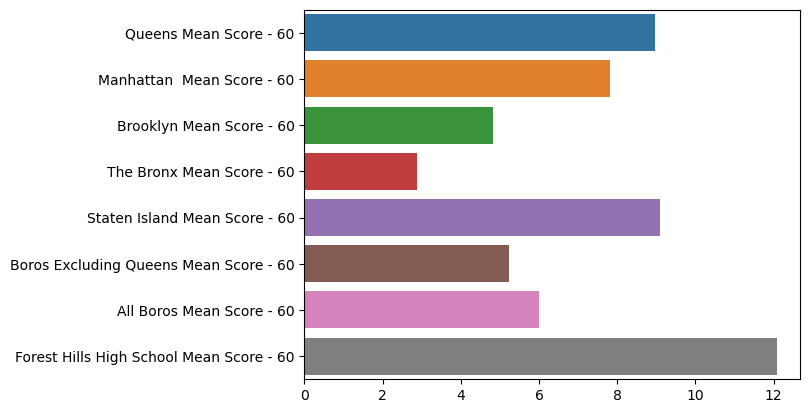

In [372]:
# Now we will create a bar plot visualization of our data
sns.barplot(data=Graph, orient='h')

In [373]:
# In conclusion, the data used provided great insight into the testing ability of NYC Public School students. Focusing on Mean Score by borough provided interesting results, if I were to perform another analysis I would separate scores by Regent Exams type. Conclusions cannot be drawn from this data set into why certain boroughs and schools performed better than others, but further analysis using other data could provide insights as to why each borough and school performed the way it did. 